## Import thư viện và khởi tạo

In [2]:
import sys
sys.path.insert(0, '..')

import matplotlib.pyplot as plt
from PIL import Image
from src.datasets.data_downloader import DocVQADownloader

# Khởi tạo downloader với cấu hình mặc định
downloader = DocVQADownloader(
    repo_id="lmms-lab/DocVQA",
    local_dir="../dataset",
    raw_folder="../dataset/DocVQA_raw",
    images_folder="../dataset/DocVQA_Images",
    labels_folder="../dataset/DocVQA_Labels"
)

print("Đã khởi tạo DocVQADownloader")

Đã khởi tạo DocVQADownloader


## Bước 1: Tải dataset từ HuggingFace

In [3]:
dataset_path = downloader.download_from_huggingface()

Dataset đã tồn tại tại: d:\Thach\HUST\Project_1\VQA\code\dataset\DocVQA
Tìm thấy 1 file parquet. Bỏ qua tải xuống.
Để tải lại, sử dụng: download_from_huggingface(force_download=True)


## Bước 2: Trích xuất ảnh từ file parquet

In [4]:
downloader.extract_images_from_parquet()

Đã tìm thấy 50,000 ảnh trong ../dataset/DocVQA_Images
Bỏ qua trích xuất. Để trích xuất lại, dùng: extract_images_from_parquet(force_extract=True)


## Bước 3: Tạo file CSV labels

In [5]:
downloader.generate_labels_csv()

Đã tìm thấy 3 file labels CSV trong ../dataset/DocVQA_Labels:
  - test_labels.csv
  - train_labels.csv
  - validation_labels.csv
Bỏ qua tạo labels. Để tạo lại, dùng: generate_labels_csv(force_generate=True)


## Thống kê Dataset

In [6]:
# Xem thống kê dataset
stats = downloader.get_dataset_stats()

print("="*50)
print("THỐNG KÊ DATASET DocVQA")
print("="*50)
for subset, count in stats.items():
    print(f"  {subset:15}: {count:,} ảnh")
print("="*50)
print(f"  {'TỔNG':15}: {sum(stats.values()):,} ảnh")

THỐNG KÊ DATASET DocVQA
  train          : 39,463 ảnh
  test           : 5,188 ảnh
  validation     : 5,349 ảnh
  TỔNG           : 50,000 ảnh


## Hiển thị ảnh mẫu

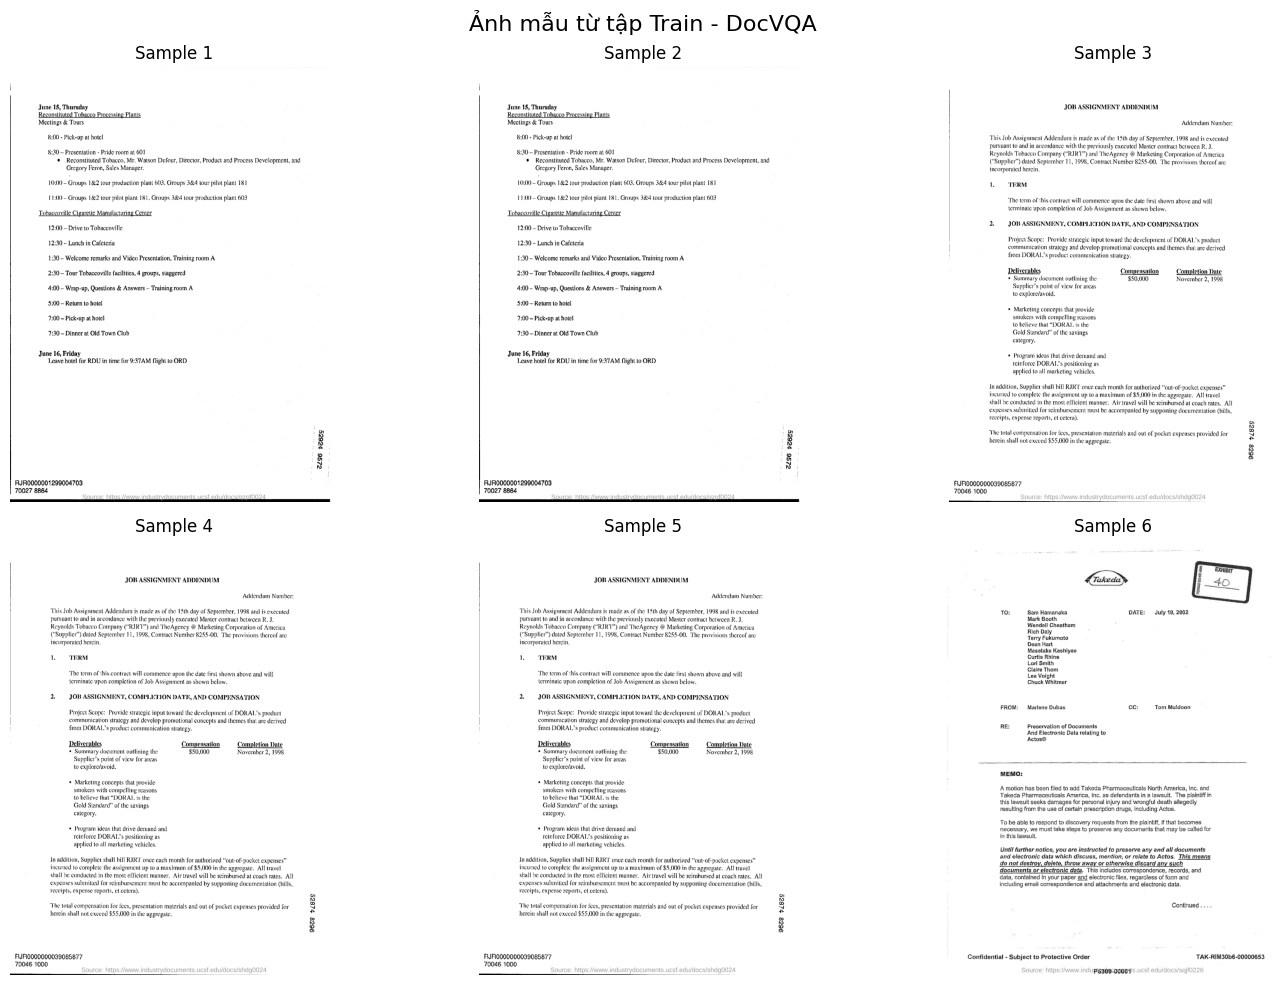

In [7]:
# Lấy ảnh mẫu từ tập train
sample_images = downloader.get_sample_images(subset="train", n_samples=6)

if sample_images:
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for idx, img_path in enumerate(sample_images):
        if idx < len(axes):
            img = Image.open(img_path)
            axes[idx].imshow(img)
            axes[idx].set_title(f"Sample {idx+1}", fontsize=12)
            axes[idx].axis('off')
    
    # Ẩn các subplot trống
    for idx in range(len(sample_images), len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle("Ảnh mẫu từ tập Train - DocVQA", fontsize=16)
    plt.tight_layout()
    plt.show()
else:
    print("Không tìm thấy ảnh mẫu. Hãy chạy các bước trước đó.")

## Xem nội dung file Labels CSV

In [8]:
import pandas as pd
import os

labels_path = "../dataset/DocVQA_Labels/train_labels.csv"

if os.path.exists(labels_path):
    df = pd.read_csv(labels_path)
    print(f"Số dòng: {len(df)}")
    print(f"\nCác cột: {df.columns.tolist()}")
    print("\n5 dòng đầu tiên:")
    display(df.head())
else:
    print(f"File {labels_path} chưa tồn tại. Hãy chạy bước tạo labels trước.")

Số dòng: 39463

Các cột: ['questionId', 'question', 'docId', 'image_filename', 'image_path', 'answers']

5 dòng đầu tiên:


,questionId,question,docId,image_filename,image_path,answers
0,337,what is the date mentioned in this letter?,279,337.png,train\337.png,['1/8/93']
1,338,what is the contact person name mentioned in l...,279,338.png,train\338.png,['P. Carter' 'p. carter']
2,339,Which corporation's letterhead is this?,280,339.png,train\339.png,['Brown & Williamson Tobacco Corporation']
3,340,Who is in cc in this letter?,280,340.png,train\340.png,['T.F. Riehl']
4,341,what is the subject of this letter?,280,341.png,train\341.png,['Review of existing Brainstorming Ideas/483']
